   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         0   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20       756  2549     9     7         19   
1        136        3  ...        905      1988  2631    17     3          7   
2        145        5  ...       1263      1716  2603    11     2          9   
3        131        6  ...       1216      1786  2769    16     8         11   
4        141        2  ...       1208      1212  1411     8     2         15   

   three_g  touch_screen  wifi  price_

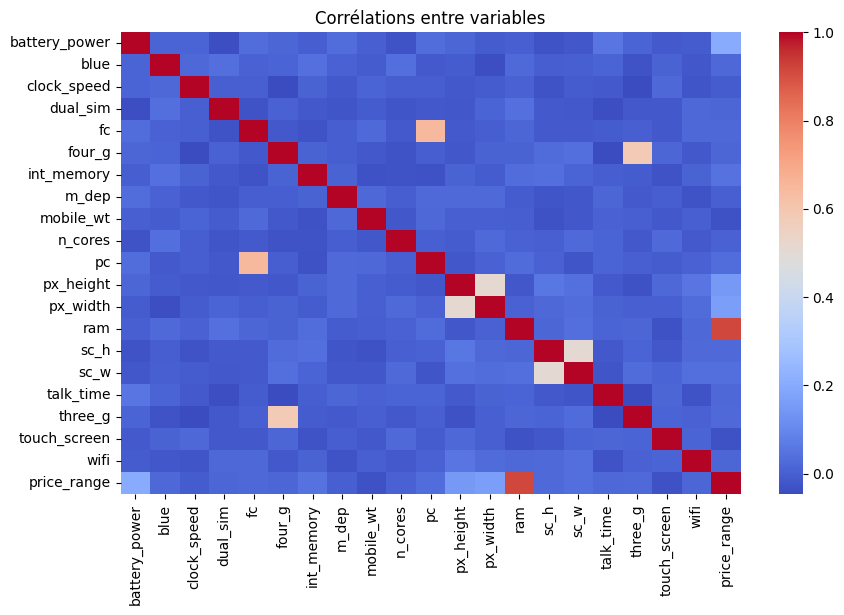

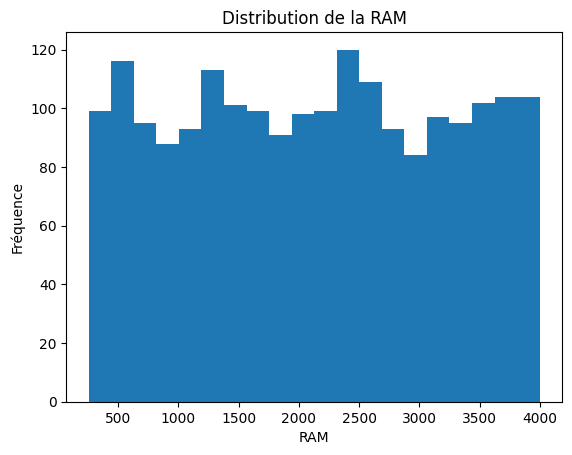

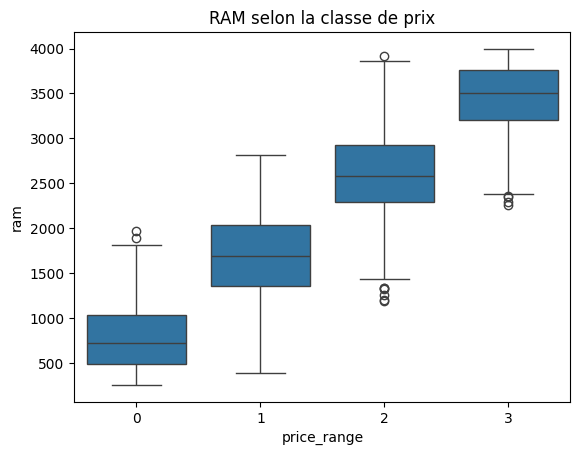

Statistique : -111.37307717748769
p-value : 0.0
Différence significative entre les groupes


In [2]:
import pandas as pd

# Charger le dataset
df = pd.read_csv("train.csv")

# Aperçu des données
print(df.head())

# Infos générales
print(df.info())

# Valeurs manquantes
print(df.isnull().sum())

# Description statistique
print(df.describe())

# Vérifier et supprimer les doublons
df = df.drop_duplicates()

# Vérifier les valeurs manquantes
df = df.dropna()

print("Données après nettoyage :", df.shape)

import numpy as np

# Exemple sur RAM et batterie
print("Moyenne RAM :", np.mean(df["ram"]))
print("Médiane RAM :", np.median(df["ram"]))
print("Écart-type RAM :", np.std(df["ram"]))

print("Moyenne batterie :", np.mean(df["battery_power"]))

import seaborn as sns
import matplotlib.pyplot as plt

# Matrice de corrélation
corr = df.corr()

print(corr["price_range"].sort_values(ascending=False))

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Corrélations entre variables")
plt.show()

plt.hist(df["ram"], bins=20)
plt.title("Distribution de la RAM")
plt.xlabel("RAM")
plt.ylabel("Fréquence")
plt.show()

sns.boxplot(x="price_range", y="ram", data=df)
plt.title("RAM selon la classe de prix")
plt.show()

from scipy.stats import ttest_ind

# Séparer deux groupes
low_price = df[df["price_range"] == 0]["ram"]
high_price = df[df["price_range"] == 3]["ram"]

# Test t
stat, p_value = ttest_ind(low_price, high_price)

print("Statistique :", stat)
print("p-value :", p_value)

if p_value < 0.05:
    print("Différence significative entre les groupes")
else:
    print("Pas de différence significative")

